In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/driver_feedback.csv")

df['is_violation'] = ((df['avg_speed_kmh'] > 80) | (df['hard_brake_event'] == 1)).astype(int)

print(f"Total trips: {len(df)}")
print(f"Violations detected: {df['is_violation'].sum()}")

X = df[['avg_speed_kmh', 'hard_brake_event']]
y = df['is_violation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Total trips: 1000
Violations detected: 85

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       184
           1       1.00      1.00      1.00        16

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



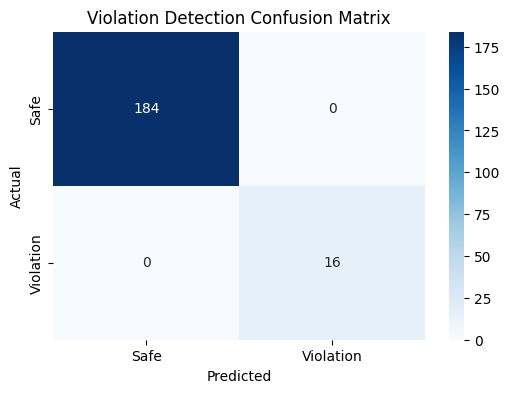

In [2]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Violation'], yticklabels=['Safe', 'Violation'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Violation Detection Confusion Matrix')
plt.show()